=============================================================================
Notebook 04: Layer 3 — Enabling Environment
Global Nutrition Monitoring Framework — UNICEF Conceptual Framework Project
Adam T. Bailes, MPH | August 2026
=============================================================================

PURPOSE
-------
This notebook serves a dual purpose:

(A) ANALYSIS: Where enabling environment data has been downloaded (WHO GINA,
    WHO Breastfeeding Scorecard, ILO Social Protection), it produces
    comparative country/regional visualizations.

(B) TOOLKIT: For indicators where standardized data is not yet widely
    available, this notebook produces a structured reference toolkit showing
    what countries SHOULD be tracking under the enabling environment domain,
    with indicator definitions, recommended data sources, and collection
    frequency.

ENABLING ENVIRONMENT DIMENSIONS (UNICEF 2020 Conceptual Framework)
------------------------------------------------------------------
  - Governance: political, financial, public/private sector actions
  - Resources: environmental, financial, social, human resources
  - Norms: gender, cultural and social norms

MAPPING TO ICN2 FRAMEWORK FOR ACTION PILLARS
--------------------------------------------
  Pillar 1: Sustainable, resilient food systems for healthy diets
  Pillar 2: Health systems providing universal coverage of nutrition actions
  Pillar 3: Social protection and nutrition education
  Pillar 4: Trade and investment for improved nutrition
  Pillar 5: Safe and supportive environments
  Pillar 6: Strengthened governance and accountability
=============================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_PROC = '../data/processed'
FIGURES   = '../outputs/figures'
TABLES    = '../outputs/tables'

In [3]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150
})

In [4]:
UNICEF_BLUE   = '#1CABE2'
UNICEF_NAVY   = '#374EA2'
UNICEF_GREEN  = '#00833D'
UNICEF_ORANGE = '#F26A21'
UNICEF_GREY   = '#6D6E71'

In [5]:
print("=" * 70)
print("NOTEBOOK 04: LAYER 3 — ENABLING ENVIRONMENT")
print("=" * 70)

NOTEBOOK 04: LAYER 3 — ENABLING ENVIRONMENT


=============================================================================
PART A: ENABLING ENVIRONMENT INDICATOR TOOLKIT
Reference table of standardized indicators with definitions,
data sources, collection frequency, and availability status.
=============================================================================

In [6]:
print("\n[1] Building enabling environment indicator reference toolkit...")


[1] Building enabling environment indicator reference toolkit...


In [7]:
TOOLKIT = [

    # --- GOVERNANCE ---
    {
        'dimension':   'Governance',
        'icn2_pillar': 'Pillar 6: Governance and accountability',
        'indicator':   'National nutrition policy or plan (Yes/No)',
        'definition':  'Existence of a current national nutrition policy, strategy, or '
                       'multi-sectoral action plan with defined targets and budget.',
        'unit':        'Binary (Yes/No)',
        'frequency':   'Annual',
        'data_source': 'WHO GINA (Global database on Implementation of Nutrition Action)',
        'data_source_url': 'https://extranet.who.int/nutrition/gina/',
        'countries_with_data': '~150',
        'availability': 'Available',
        'notes': 'SUN Movement annual reporting also tracks this for 60+ member countries.'
    },
    {
        'dimension':   'Governance',
        'icn2_pillar': 'Pillar 6: Governance and accountability',
        'indicator':   'Functional multisectoral nutrition coordination mechanism (Yes/No)',
        'definition':  'Existence of a government-led, multisectoral body with mandate, '
                       'membership, and meeting schedule for nutrition coordination.',
        'unit':        'Binary (Yes/No)',
        'frequency':   'Annual',
        'data_source': 'SUN Movement annual reporting; WHO GINA',
        'data_source_url': 'https://scalingupnutrition.org/progress-impact/monitoring-evaluation-accountability-and-learning/',
        'countries_with_data': '~65 (SUN); ~120 (GINA)',
        'availability': 'Available',
        'notes': 'SUN uses structured assessment; GINA uses self-reported data.'
    },
    {
        'dimension':   'Governance',
        'icn2_pillar': 'Pillar 6: Governance and accountability',
        'indicator':   'Dedicated government budget line for nutrition (Yes/No + % GDP)',
        'definition':  'Whether a government has a discrete budget line for nutrition '
                       'programmes (not embedded in health or agriculture sector). '
                       'Optional: nutrition expenditure as % of GDP.',
        'unit':        'Binary + % GDP (optional)',
        'frequency':   'Annual',
        'data_source': 'SUN Movement; OECD CRS aid data; national budget documents',
        'data_source_url': 'https://scalingupnutrition.org/',
        'countries_with_data': '~50 (SUN reporting)',
        'availability': 'Partial — limited to SUN member countries',
        'notes': 'Significant data gap. Nutrition financing tracking is a recognized '
                 'gap in the GNMF. New guide should flag this as a recommended tracker.'
    },
    {
        'dimension':   'Governance',
        'icn2_pillar': 'Pillar 2: Health systems nutrition actions',
        'indicator':   'WHO Code compliance (BFMS marketing restrictions)',
        'definition':  'Whether national legislation substantially complies with the '
                       'International Code of Marketing of Breast-milk Substitutes (1981), '
                       'as assessed by WHO/UNICEF.',
        'unit':        'Score: No measures / Some measures / Substantial measures / '
                       'Full Code in law',
        'frequency':   'Every 2-3 years (WHO assessment cycle)',
        'data_source': 'WHO Breastfeeding Scorecard; WHO GINA',
        'data_source_url': 'https://www.who.int/publications/i/item/9789240018389',
        'countries_with_data': '~150',
        'availability': 'Available',
        'notes': 'WHO Global BF Scorecard (2023 edition) is the most recent assessment. '
                 'Scores on 1-10 scale; above 8 considered substantial compliance.'
    },
    {
        'dimension':   'Governance',
        'icn2_pillar': 'Pillar 1: Food systems for healthy diets',
        'indicator':   'Mandatory food fortification legislation (Yes/No by nutrient)',
        'definition':  'Whether national legislation mandates fortification of staple foods '
                       '(wheat flour, maize flour, rice, edible oil, salt) with specific '
                       'micronutrients (iron, folic acid, vitamin A, iodine, zinc).',
        'unit':        'Binary per food vehicle and nutrient',
        'frequency':   'Annual update',
        'data_source': 'Food Fortification Initiative (FFI) country tracker; WHO GINA',
        'data_source_url': 'https://www.ffinetwork.org/country-profiles',
        'countries_with_data': '~160',
        'availability': 'Available',
        'notes': 'FFI maintains the most comprehensive and up-to-date database. '
                 'WHO GINA also tracks this but updates are slower.'
    },

    # --- RESOURCES ---
    {
        'dimension':   'Resources',
        'icn2_pillar': 'Pillar 2: Health systems nutrition actions',
        'indicator':   'Maternity leave duration (weeks) meeting WHO/ILO standard',
        'definition':  'Statutory paid maternity leave duration in weeks. '
                       'ILO Maternity Protection Convention C183 (2000) recommends '
                       'minimum 14 weeks. WHO recommends minimum 18 weeks to support EBF.',
        'unit':        'Weeks (statutory)',
        'frequency':   'Annual',
        'data_source': 'ILO Working Conditions Laws Database; WHO BF Scorecard',
        'data_source_url': 'https://www.ilo.org/ilolex/english/newcountryframeE.htm',
        'countries_with_data': '~170',
        'availability': 'Available',
        'notes': 'ILO WCLD provides statutory duration; enforcement/coverage varies. '
                 'WHO Scorecard uses 18-week threshold for scoring.'
    },
    {
        'dimension':   'Resources',
        'icn2_pillar': 'Pillar 3: Social protection',
        'indicator':   'Social protection coverage — maternity benefit (% of women)',
        'definition':  'Percentage of women giving birth who receive a maternity cash '
                       'benefit from social insurance or social assistance systems.',
        'unit':        'Percentage (%)',
        'frequency':   'Every 2-3 years',
        'data_source': 'ILO World Social Protection Report; ILO ILOSTAT',
        'data_source_url': 'https://ilostat.ilo.org/topics/social-protection/',
        'countries_with_data': '~150',
        'availability': 'Available',
        'notes': 'ILO 2024 World Social Protection Report provides most recent estimates. '
                 'SDG indicator 1.3.1 measures social protection coverage broadly.'
    },
    {
        'dimension':   'Resources',
        'icn2_pillar': 'Pillar 3: Social protection',
        'indicator':   'Coverage of social protection cash transfers (% population)',
        'definition':  'Percentage of population in the lowest income quintile covered '
                       'by at least one social protection programme (cash transfer, '
                       'in-kind transfer, or public works).',
        'unit':        'Percentage (%) — poorest quintile',
        'frequency':   'Annual (ILO/World Bank)',
        'data_source': 'World Bank ASPIRE database; ILO ILOSTAT',
        'data_source_url': 'https://www.worldbank.org/en/data/datatopics/aspire',
        'countries_with_data': '~120',
        'availability': 'Available',
        'notes': 'ASPIRE is the most comprehensive social protection coverage database. '
                 'Nutrition-sensitive social protection linkage is an emerging indicator area.'
    },
    {
        'dimension':   'Resources',
        'icn2_pillar': 'Pillar 2: Health systems nutrition actions',
        'indicator':   'Health worker density (per 10,000 population)',
        'definition':  'Density of doctors, nurses, and midwives per 10,000 population. '
                       'WHO minimum threshold: 44.5 per 10,000 for basic service coverage. '
                       'Proxy for health system capacity to deliver nutrition services.',
        'unit':        'Per 10,000 population',
        'frequency':   'Annual',
        'data_source': 'WHO Global Health Workforce Statistics; NHWA portal',
        'data_source_url': 'https://www.who.int/data/gho/data/themes/topics/health-workforce',
        'countries_with_data': '~190',
        'availability': 'Available',
        'notes': 'Available through WHO GHO API. Widely used as health system capacity proxy.'
    },

    # --- NORMS ---
    {
        'dimension':   'Norms',
        'icn2_pillar': 'Pillar 5: Safe and supportive environments',
        'indicator':   "Women's empowerment index (WEAI or similar)",
        'definition':  "Composite measure of women's empowerment in agriculture and "
                       'household decision-making, including control over food production '
                       'and dietary decisions. WEAI is validated for use in LMIC contexts.',
        'unit':        'Index (0-1)',
        'frequency':   'Every 5 years (DHS cycle)',
        'data_source': 'IFPRI WEAI; DHS women empowerment modules',
        'data_source_url': 'https://www.ifpri.org/project/weai',
        'countries_with_data': '~60 (WEAI); broader through DHS proxy indicators',
        'availability': 'Partial — not globally standardized',
        'notes': 'Known data gap in the GNMF. DHS collects proxy indicators on '
                 'household decision-making but not a composite index. '
                 'Recommended for inclusion in new guide as an emerging indicator.'
    },
    {
        'dimension':   'Norms',
        'icn2_pillar': 'Pillar 5: Safe and supportive environments',
        'indicator':   'Breastfeeding support in the workplace (Yes/No)',
        'definition':  'Existence of legal provisions requiring employers to provide '
                       'breastfeeding breaks and facilities for nursing mothers. '
                       'WHO BF Scorecard assesses this as part of the breastfeeding '
                       'enabling environment score.',
        'unit':        'Binary (Yes/No)',
        'frequency':   'Every 2-3 years (WHO BF Scorecard cycle)',
        'data_source': 'WHO Global Breastfeeding Scorecard; ILO WCLD',
        'data_source_url': 'https://www.who.int/publications/i/item/9789240018389',
        'countries_with_data': '~150',
        'availability': 'Available',
        'notes': 'WHO Scorecard 2023 edition. ILO WCLD confirms legislative basis.'
    },
    {
        'dimension':   'Norms',
        'icn2_pillar': 'Pillar 1: Food systems for healthy diets',
        'indicator':   'Availability of nutritious foods (Cost of Healthy Diet, $/day)',
        'definition':  'Cost of a least-cost diet that meets nutrient requirements for '
                       'one adult for one day (FAO/WFP/IFPRI cost of a healthy diet '
                       'metric). Proxy for whether healthy foods are economically '
                       'accessible in a given country.',
        'unit':        'USD per day per person (PPP-adjusted)',
        'frequency':   'Annual',
        'data_source': 'FAO/WFP/IFPRI Cost of a Healthy Diet (CAHD) indicator; SOFI Annex',
        'data_source_url': 'https://www.fao.org/publications/fao-flagship-publications/'
                           'the-state-of-food-security-and-nutrition-in-the-world/en',
        'countries_with_data': '~170',
        'availability': 'Available (SOFI 2025 annex)',
        'notes': 'Included in SOFI 2025 data annex. Directly featured in SOFI 2026 '
                 'as focus indicator on food system affordability.'
    },
]

In [8]:
df_toolkit = pd.DataFrame(TOOLKIT)
df_toolkit.to_csv(f'{TABLES}/layer3_enabling_environment_toolkit.csv', index=False)
print(f"  Created toolkit with {len(df_toolkit)} indicators across "
      f"{df_toolkit['dimension'].nunique()} dimensions")
print(f"  Saved: layer3_enabling_environment_toolkit.csv")

  Created toolkit with 12 indicators across 3 dimensions
  Saved: layer3_enabling_environment_toolkit.csv


=============================================================================
FIGURE 8: Enabling Environment Toolkit — visual summary
=============================================================================

In [9]:
print("\n[2] Generating enabling environment toolkit visualization...")


[2] Generating enabling environment toolkit visualization...


In [10]:
avail_counts = df_toolkit.groupby(['dimension', 'availability']).size().unstack(fill_value=0)

In [11]:
colors_avail = {
    'Available': UNICEF_GREEN,
    'Partial — limited to SUN member countries': UNICEF_ORANGE,
    'Partial — not globally standardized': UNICEF_ORANGE,
}

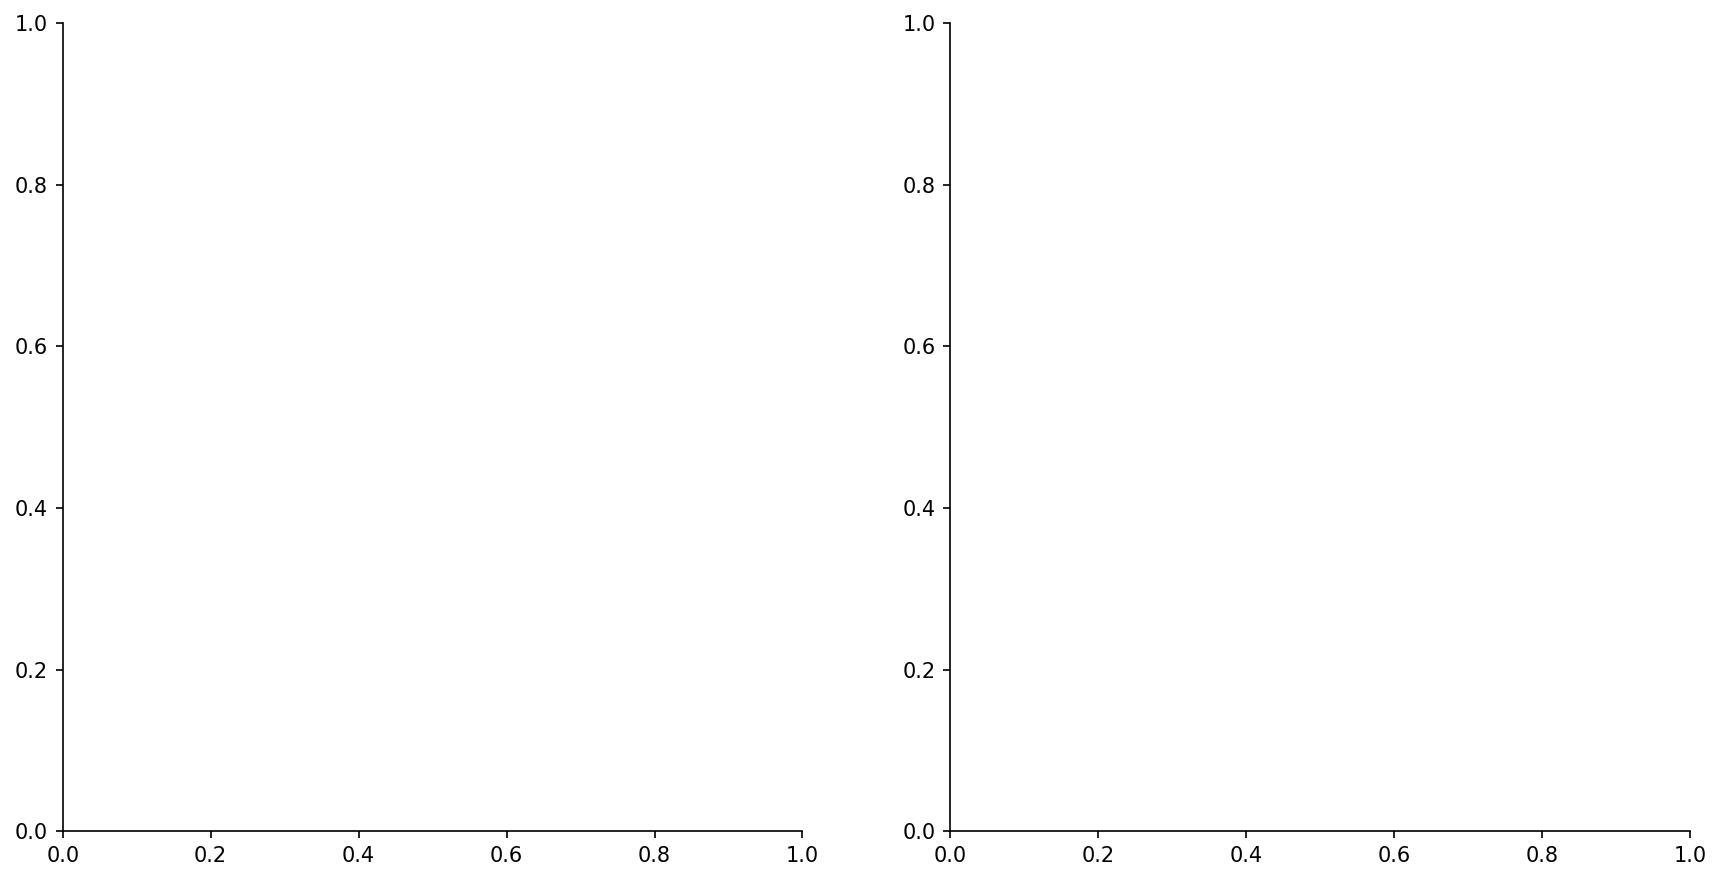

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

In [13]:
# Panel A: indicator count by dimension and availability
ax = axes[0]
dimensions = df_toolkit['dimension'].unique()
avail_cats = df_toolkit['availability'].unique()

In [14]:
x = np.arange(len(dimensions))
width = 0.25
for i, avail in enumerate(avail_cats):
    vals = [len(df_toolkit[(df_toolkit['dimension'] == d) &
                            (df_toolkit['availability'] == avail)])
            for d in dimensions]
    color = UNICEF_GREEN if avail == 'Available' else UNICEF_ORANGE
    ax.bar(x + i * width, vals, width,
           label=avail if avail != 'Partial — limited to SUN member countries'
                       else 'Partial',
           color=color, alpha=0.85)

In [15]:
ax.set_xticks(x + width)
ax.set_xticklabels(dimensions, fontsize=11)
ax.set_ylabel('Number of Indicators', fontsize=10)
ax.set_title('Enabling Environment Indicators\nby Dimension and Data Availability',
             fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0, max(avail_counts.sum(axis=1)) + 1)

(0.0, 6.0)

In [16]:
# Panel B: ICN2 pillar coverage
ax2 = axes[1]
pillar_counts = (df_toolkit.groupby('icn2_pillar')
                 .size()
                 .sort_values(ascending=True))

In [17]:
colors_bar = [UNICEF_BLUE if 'Health' in p or 'Social' in p
              else UNICEF_NAVY if 'Governance' in p
              else UNICEF_GREEN if 'Food' in p
              else UNICEF_ORANGE
              for p in pillar_counts.index]

In [18]:
ax2.barh(range(len(pillar_counts)), pillar_counts.values,
         color=colors_bar, alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(pillar_counts)))
ax2.set_yticklabels([p.replace('Pillar ', 'P').split(':')[0] + ':' +
                     p.split(':')[1][:35]
                     for p in pillar_counts.index],
                    fontsize=8)
ax2.set_xlabel('Number of Indicators', fontsize=10)
ax2.set_title('ICN2 Framework for Action — Pillar Coverage\nin Enabling Environment Toolkit',
              fontweight='bold')
ax2.tick_params(axis='y', labelsize=8)

In [19]:
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig07_enabling_environment_toolkit.png',
            bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("  Saved: fig07_enabling_environment_toolkit.png")

<Figure size 960x720 with 0 Axes>

  Saved: fig07_enabling_environment_toolkit.png


=============================================================================
PART B: LOAD AND ANALYZE AVAILABLE ENABLING ENVIRONMENT DATA
=============================================================================

In [20]:
print("\n[3] Loading available enabling environment data...")


[3] Loading available enabling environment data...


In [21]:
# WHO GINA
gina_path = f'{DATA_PROC}/who_gina_clean.csv'
if os.path.exists(gina_path):
    df_gina = pd.read_csv(gina_path)
    print(f"  WHO GINA: {len(df_gina):,} rows — generating policy coverage charts...")

    # Policy existence by region would go here
    # (Column structure varies by GINA download — adapt to actual file)
else:
    print("  WHO GINA not available (manual download required)")

  WHO GINA not available (manual download required)


In [22]:
# WHO Breastfeeding Scorecard
bfsc_path = f'{DATA_PROC}/who_bfsc_clean.csv'
if os.path.exists(bfsc_path):
    df_bfsc = pd.read_csv(bfsc_path)
    print(f"  WHO BF Scorecard: {len(df_bfsc):,} rows — generating scorecard analysis...")
else:
    print("  WHO BF Scorecard not available (manual download required)")

  WHO BF Scorecard not available (manual download required)


In [23]:
# ILO Social Protection
ilo_path = f'{DATA_PROC}/ilo_sp_clean.csv'
if os.path.exists(ilo_path):
    df_ilo = pd.read_csv(ilo_path)
    print(f"  ILO Social Protection: {len(df_ilo):,} rows — generating coverage analysis...")
else:
    print("  ILO Social Protection not available (manual download required)")

  ILO Social Protection not available (manual download required)


=============================================================================
FIGURE 9: Tableau-ready enabling environment summary
=============================================================================

In [24]:
print("\n[4] Exporting Tableau-ready enabling environment files...")


[4] Exporting Tableau-ready enabling environment files...


In [25]:
df_toolkit.to_csv(f'{TABLES}/tableau_layer3_toolkit.csv', index=False)

In [26]:
# Summary table for dashboard
summary = pd.DataFrame({
    'Framework Layer':    ['Layer 3: Enabling Environment'] * 3,
    'Dimension':          ['Governance', 'Resources', 'Norms'],
    'Indicators in toolkit': [
        len(df_toolkit[df_toolkit['dimension'] == 'Governance']),
        len(df_toolkit[df_toolkit['dimension'] == 'Resources']),
        len(df_toolkit[df_toolkit['dimension'] == 'Norms']),
    ],
    'Data available now': [
        len(df_toolkit[(df_toolkit['dimension'] == 'Governance') &
                       (df_toolkit['availability'] == 'Available')]),
        len(df_toolkit[(df_toolkit['dimension'] == 'Resources') &
                       (df_toolkit['availability'] == 'Available')]),
        len(df_toolkit[(df_toolkit['dimension'] == 'Norms') &
                       (df_toolkit['availability'] == 'Available')]),
    ],
    'Data gap (partial or none)': [
        len(df_toolkit[(df_toolkit['dimension'] == 'Governance') &
                       (df_toolkit['availability'] != 'Available')]),
        len(df_toolkit[(df_toolkit['dimension'] == 'Resources') &
                       (df_toolkit['availability'] != 'Available')]),
        len(df_toolkit[(df_toolkit['dimension'] == 'Norms') &
                       (df_toolkit['availability'] != 'Available')]),
    ],
})
summary.to_csv(f'{TABLES}/layer3_dimension_summary.csv', index=False)
print("  Saved: tableau_layer3_toolkit.csv")
print("  Saved: layer3_dimension_summary.csv")

  Saved: tableau_layer3_toolkit.csv
  Saved: layer3_dimension_summary.csv


In [27]:
print("\n[DONE] Notebook 04 complete. Run 05_integrated_analysis.py next.")


[DONE] Notebook 04 complete. Run 05_integrated_analysis.py next.
